Цель — определить, какие клиенты положительно отреагируют на предложение о страховании автомобиля.
---


In [121]:

import pandas as pd
import numpy as np

import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, levene, mannwhitneyu
import pingouin as pg

#from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [122]:
data = pd.read_csv(r'C:\Users\tsyto\Downloads\playground-series-s4e7\train.csv').sample(frac=0.01, random_state=11)
data.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
10879447,10879447,Female,21,1,8.0,1,< 1 Year,No,40897.0,160.0,173,0
6464385,6464385,Female,48,1,3.0,0,> 2 Years,Yes,33222.0,124.0,157,1
9428771,9428771,Female,38,1,33.0,1,1-2 Year,No,28324.0,152.0,110,0
11210897,11210897,Female,53,1,6.0,1,1-2 Year,No,28244.0,152.0,219,0
10945328,10945328,Female,21,1,8.0,1,< 1 Year,No,34761.0,160.0,232,0


In [123]:
data.shape

(115048, 12)

In [124]:
data.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

'Gender' - гендер,Female/Male;

'Age' - возраст; 

'Driving_License' - водительское удостоверение, 1 - есть/2 - нет;

'Region_Code' - код региона проживания или что-то в этом роде, отражает географию;

'Previously_Insured' - ранее застрахован, 1 - да/0 - нет(первая страховка);

'Vehicle_Age' - возраст трансопртного средства; 

'Vehicle_Damage' - повреждения авто;

'Annual_Premium' - сумма, которую клиент оплачивает по текущей страховке;

'Policy_Sales_Channel' - идентификатор канала, через который клиенту предлагался полис;

'Vintage' - стаж клиента, в днях;  

'Response' - целевая метрика 0 и 1.

In [125]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115048 entries, 10879447 to 4090682
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    115048 non-null  int64  
 1   Gender                115048 non-null  object 
 2   Age                   115048 non-null  int64  
 3   Driving_License       115048 non-null  int64  
 4   Region_Code           115048 non-null  float64
 5   Previously_Insured    115048 non-null  int64  
 6   Vehicle_Age           115048 non-null  object 
 7   Vehicle_Damage        115048 non-null  object 
 8   Annual_Premium        115048 non-null  float64
 9   Policy_Sales_Channel  115048 non-null  float64
 10  Vintage               115048 non-null  int64  
 11  Response              115048 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 11.4+ MB


Полное отсутсвие пропусков данных в нашем датасете.

In [126]:
#Проверим целевую метрику на дисбаланс 
data.Response.value_counts(normalize=True)

Response
0    0.876591
1    0.123409
Name: proportion, dtype: float64

In [127]:

data.groupby('Previously_Insured', as_index=False).Age.median()
#клиенты, которые уже имели страховку, имеют мЕньший средний возраст

,Previously_Insured,Age
0,0,43.0
1,1,27.0


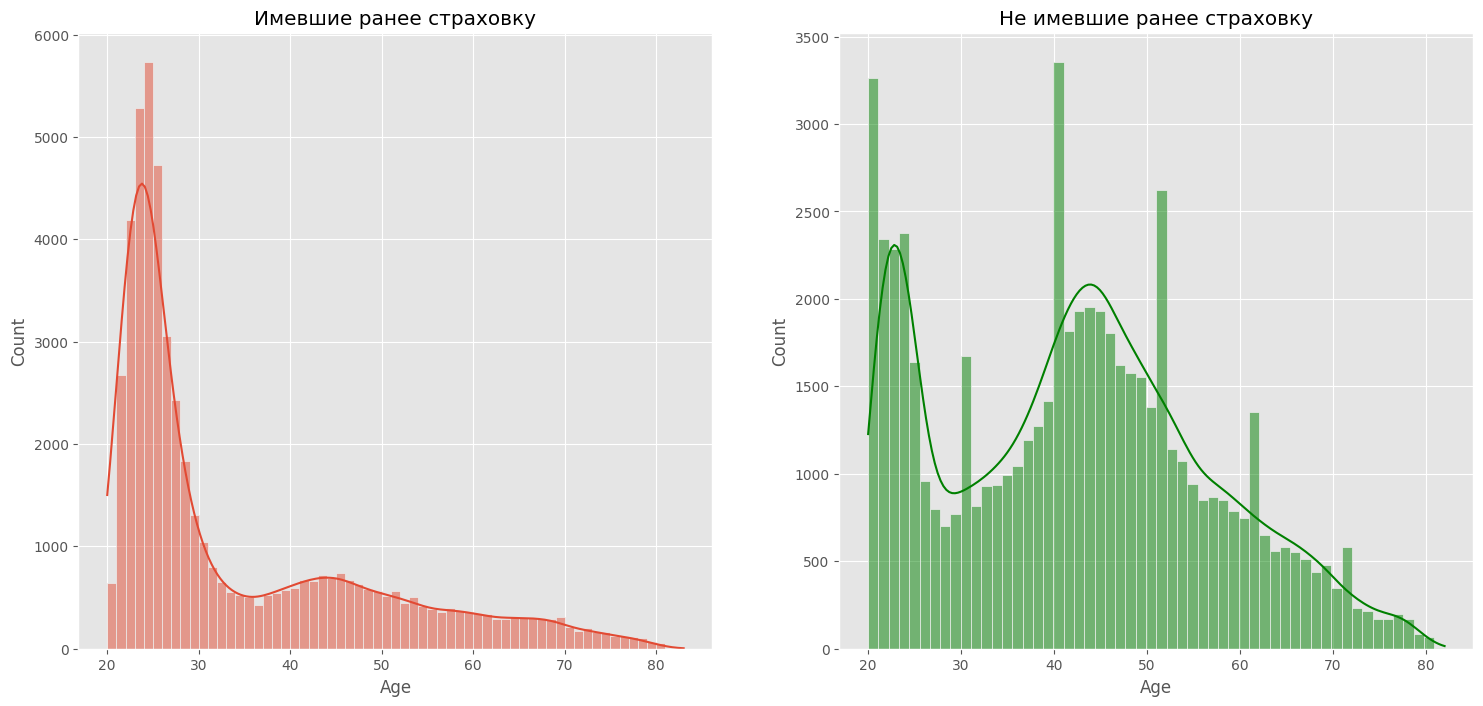

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.histplot(data.query('Previously_Insured == 1').Age, kde=True,ax=axes[0])
axes[0].set_title('Имевшие ранее страховку')
sns.histplot(data.query('Previously_Insured == 0').Age, kde=True, color='green', ax=axes[1])
axes[1].set_title('Не имевшие ранее страховку')

plt.show()

In [129]:
group_1 = data.query('Previously_Insured == 1').Age #Была ранее страховка
group_2 = data.query('Previously_Insured == 0').Age #Не было ранее страховки

In [130]:
describe_tab = pd.concat([group_1.describe().rename('Была страховка'),
                          group_2.describe().rename('Не ыбло страховки')], axis=1)
print(describe_tab)

       Была страховка  Не ыбло страховки
count    53454.000000       61594.000000
mean        33.938059          42.313781
std         14.381144          14.400157
min         20.000000          20.000000
25%         24.000000          30.000000
50%         27.000000          43.000000
75%         43.000000          52.000000
max         83.000000          82.000000


In [131]:
pg.normality(data=data,dv='Age',group='Previously_Insured', method='normaltest')

,W,pval,normal
Previously_Insured,,,
1,9168.91999,0.0,False
0,3781.91076,0.0,False


In [132]:
levene(data.query('Previously_Insured == 1').Age, data.query('Previously_Insured == 0').Age)

LeveneResult(statistic=np.float64(549.6700211585129), pvalue=np.float64(2.864456646160806e-121))

Имеем:
 - неравенство дисперсий,
 - ненормальность распределений, сильно скошенные распределения, одно и вовсе похоже на бимодальное.
С помощью критерия Манна-Уитни проверим, действительно ли етсь разница средних значений между группами. 

In [133]:
stat, p_val = mannwhitneyu(group_1, group_2)
print(p_val)

0.0


Различия средних значений статичтически значимо
---

In [134]:
n1, n2= len(group_1), len(group_2)
r = 1 - (2 * stat) / (n1 * n2) # Посчитаем размер эффекта - [0,1] 
print(f'{r:.2f} - величина имеющегося эффекта разницы двух групп')

0.33 - величина имеющегося эффекта разницы двух групп


Подытожим, что разница в данных группах ЗАМЕТНАЯ, в чем можно убедиться на полученном размере эффекта. На распределениях видно, что возрастные группы имевших и не имевших ранее страховки пересекаются, но бОльшая часть группы, которая имела ранее страховку, - моложе.

---

Взглянем на расширенные группы с разбиением по целевой метрике тех кто имел ранее страховку и нет - посмотрим на их распределения.

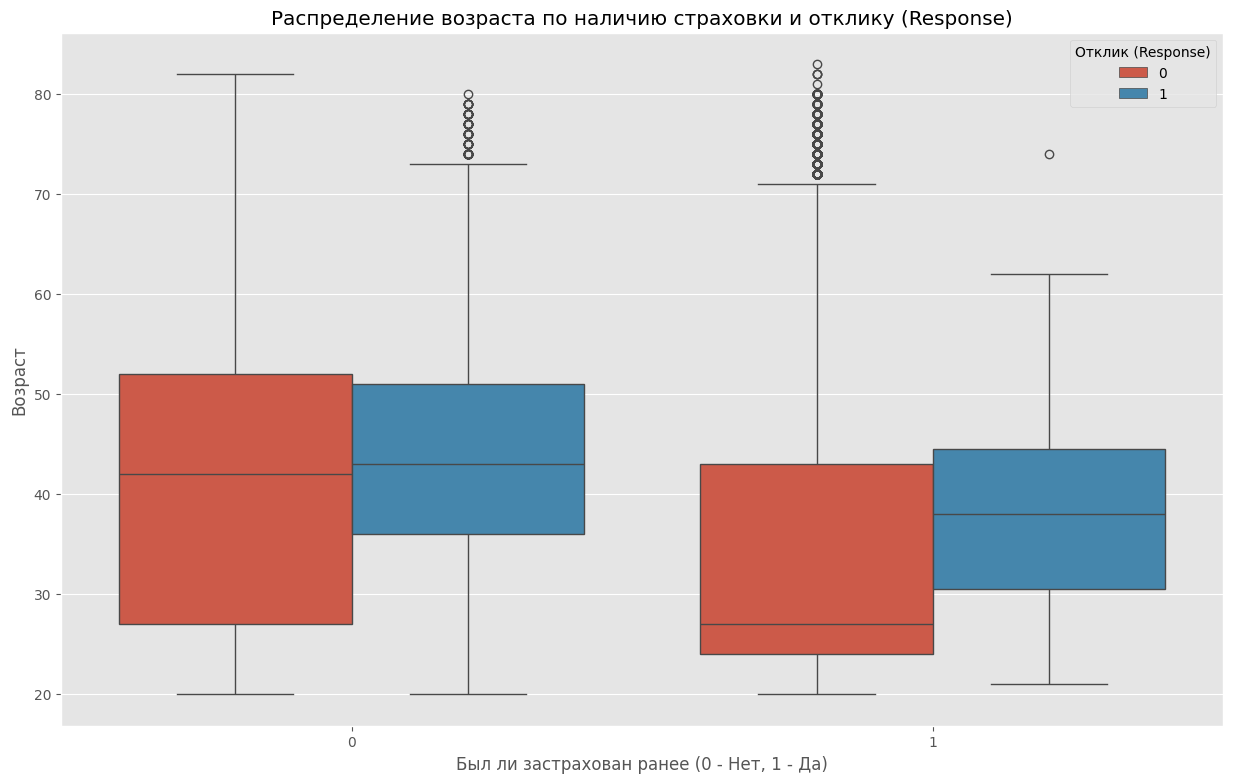

In [135]:
import matplotlib as mpl
mpl.style.use('ggplot')

plt.figure(figsize=(15, 9))
sns.boxplot(data=data, x='Previously_Insured', y='Age', hue='Response')

plt.title('Распределение возраста по наличию страховки и отклику (Response)')
plt.xlabel('Был ли застрахован ранее (0 - Нет, 1 - Да)')
plt.ylabel('Возраст')
plt.legend(title='Отклик (Response)', loc='upper right')
plt.show()

Можем обратить внимание:
 - молодые люди до 30 лет практически все негативно реагируют на прелдложение;
 - "наш клиент" от 30 лет, если имелись страховки ранее, и от 35 лет, елси не имелись.
 -  ранее застрахованы были в основном молодые люди, и среди них положительно откликнушиеся страше медианного значения во группе 1.
 
 ...

In [136]:
pd.crosstab(data['Previously_Insured'], data['Response']).style.background_gradient(cmap='summer_r')

Response,0,1
Previously_Insured,,
0,47427,14167
1,53423,31


Важная информация - если у человека уже была ранее страховка оформлена, то он с огромной долей вероятности негативно отреагирует, конверсия в районе 0,05%. Возможно с этой группой совершенно не стоит работать. Previously_Insured = 1 — это «мертвая» зона.

Обновляем нашу цель - те, у кого не было ранее страховки и возраст от 35 лет.



----

In [137]:
#Бесполезный признак наличия водительского удостовения, можно будет удалить перед обучением моделей, таккак практически не представлен, что логично.
data['Driving_License'].value_counts()

Driving_License
1    114833
0       215
Name: count, dtype: int64

----

In [138]:
f'Имеем {data['Region_Code'].nunique()} уникальных значений признака Region_Code'

'Имеем 53 уникальных значений признака Region_Code'

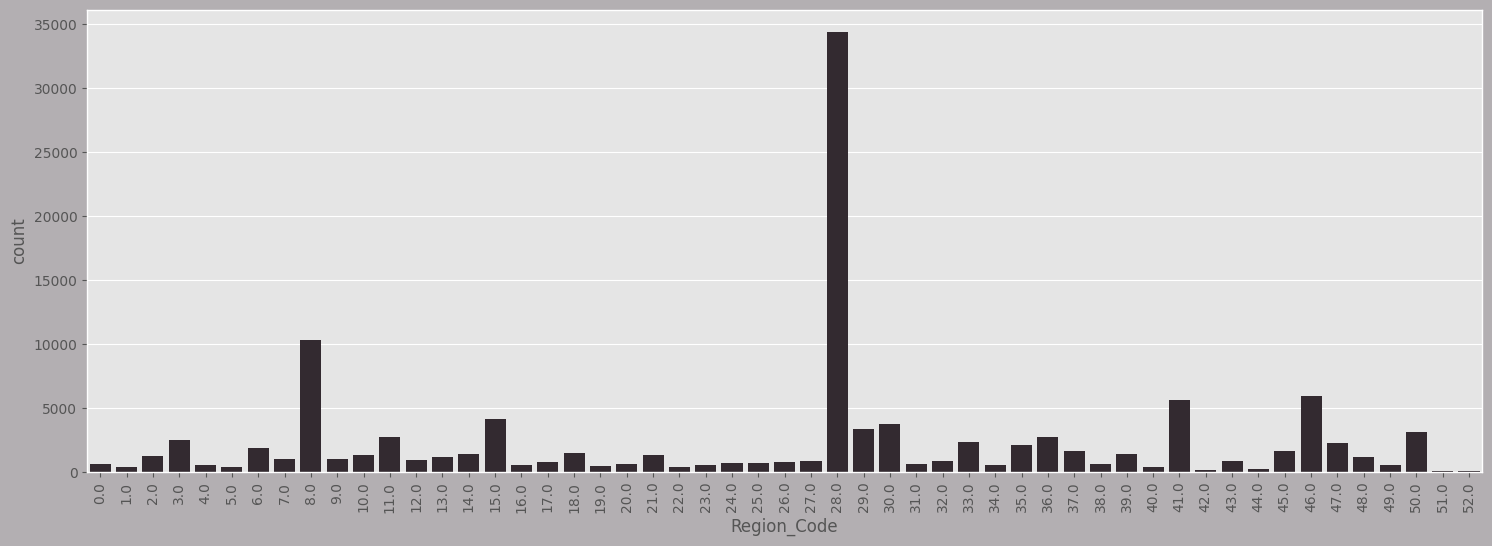

In [139]:
plt.figure(figsize=(18, 6), facecolor="#B3AFB2")
sns.barplot(data.Region_Code.value_counts(), color="#342931")
plt.xticks(rotation=90)
plt.show()

In [140]:
region_conversion = pd.crosstab(data['Region_Code'], data['Response'])
region_conversion['conversion'] = round((region_conversion[1]/(region_conversion[1]+region_conversion[0])),2)
region_conversion.sort_values(by='conversion', ascending=False).T

Region_Code,23.0,28.0,38.0,19.0,7.0,39.0,4.0,29.0,24.0,3.0,...,15.0,10.0,50.0,17.0,22.0,21.0,16.0,25.0,52.0,44.0
Response,,,,,,,,,,,,,,,,,,,,,
0,434.00,27768.00,477.00,349.00,807.00,1173.00,410.00,2896.00,575.00,2116.00,...,3846.00,1188.00,2936.00,674.00,333.00,1227.00,508.00,635.00,36.00,164.00
1,101.00,6625.00,108.00,71.00,139.00,201.00,66.00,420.00,88.00,319.00,...,261.00,71.00,179.00,45.00,23.00,78.00,24.00,34.00,2.00,4.00
conversion,0.19,0.19,0.18,0.17,0.15,0.15,0.14,0.13,0.13,0.13,...,0.06,0.06,0.06,0.06,0.06,0.06,0.05,0.05,0.05,0.02


Видим огромное количество для регионов - в исходном виде получим  много шума при кодировании данного признака, попробуем воспользоваться Target Encoding - заменим данный признак на один единственный , который будет содержать float данные с этими самыми значениями конверсии, с неким сглаживанием с оглядкой на количество наблюдений в этой группе. Разделим позже на 4 группы по уровню конверсии.

----

Взглянем на признаки, сообщающие о возрасте авто и наличии аварий. Посмотрим так же на конврерсию, попробуем сделать общие выводы.

In [141]:
pd.crosstab(data['Vehicle_Age'], data['Response']).style.background_gradient(cmap='summer_r')

Response,0,1
Vehicle_Age,,
1-2 Year,49217,10661
< 1 Year,48243,2043
> 2 Years,3390,1494


In [142]:
veh_age_conversion = pd.crosstab(data['Vehicle_Age'], data['Response'])
veh_age_conversion['conversion'] = round((veh_age_conversion[1]/(veh_age_conversion[1]+veh_age_conversion[0])),2)
veh_age_conversion.sort_values(by='conversion', ascending=False).style.background_gradient(cmap='summer_r')

Response,0,1,conversion
Vehicle_Age,,,
> 2 Years,3390,1494,0.310000
1-2 Year,49217,10661,0.180000
< 1 Year,48243,2043,0.040000


По возрасту авто можем сказать , что конверсия значительно выше в категории > 2 Years.

In [143]:
veh_age_conversion = pd.crosstab([data['Vehicle_Age'], data['Vehicle_Damage']], data['Response'])
veh_age_conversion['conversion'] = round((veh_age_conversion[1]/(veh_age_conversion[1]+veh_age_conversion[0])),2)
veh_age_conversion.sort_values(by='conversion', ascending=False).style.background_gradient(cmap='summer_r')

,Response,0,1,conversion
Vehicle_Age,Vehicle_Damage,,,
> 2 Years,Yes,3385,1493,0.310000
1-2 Year,Yes,28135,10525,0.270000
> 2 Years,No,5,1,0.170000
< 1 Year,Yes,12133,1959,0.140000
1-2 Year,No,21082,136,0.010000
< 1 Year,No,36110,84,0.000000


Теперь можем сказать, что скорее влияет наличии аварий. В последующем обработаем данные категориальные признаки через OneHotEncoding - из двух признаков получим всего 5 колонок - терпимо, признаки потенциально оч важные.

----

Annual_Premium -  сумма, которую клиент оплачивает по текущей страховке.
---

In [144]:
data.Annual_Premium.describe()

count    115048.000000
mean      30400.181794
std       16253.363849
min        2630.000000
25%       25252.000000
50%       31824.000000
75%       39423.000000
max      489509.000000
Name: Annual_Premium, dtype: float64

In [145]:
data.Annual_Premium.mode()

0    2630.0
Name: Annual_Premium, dtype: float64

In [146]:
data[data['Annual_Premium'] == 2630].shape

(21227, 12)

In [147]:
#Большая часть пользователей оплачивает "минимальный тариф". 
data['min_premium'] = (data['Annual_Premium'] == 2630).astype(int)

data.groupby('min_premium')['Response'].mean()

min_premium
0    0.121934
1    0.129929
Name: Response, dtype: float64

In [148]:
data = data.drop('min_premium', axis=1)

Среди тех, кто платит минималку и других - одинаковая доля положительного отклика/заинтересованности по целевой метрике.

Вернемся ко всем значениям, посмотреть на выбросы в отдельности и без них.

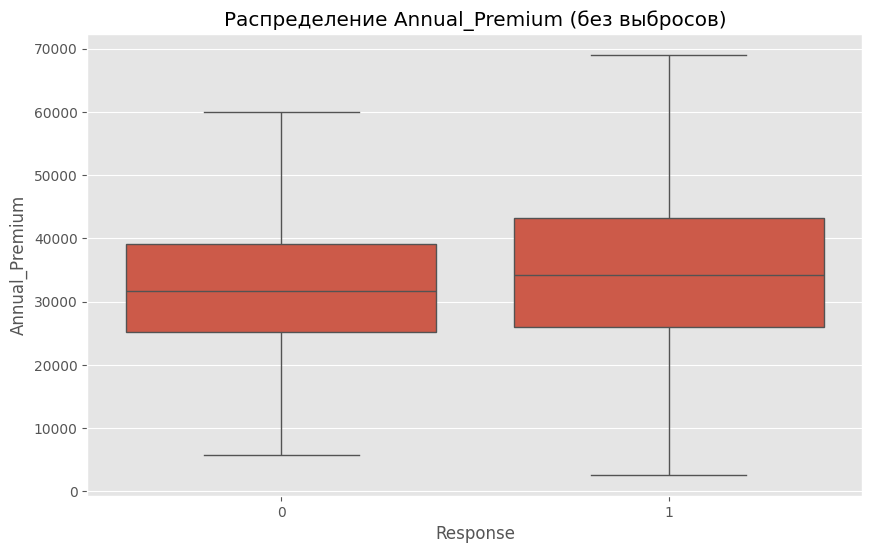

In [149]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Response', y='Annual_Premium', showfliers=False) #Без ограничения выбросов боксплот грузится через раз , возмоно их оч много
plt.title('Распределение Annual_Premium (без выбросов)')
plt.show()

Видим в наших данных, что медиана у 1 чуть выше, как и сама коробка, то есть люди, которые платят чуть выше среднего охотнее соглашаются на новое предложение.

Так же в описательной таблице выше видели, что скорее всего присутствуют экстремально высокие значения, скорее всего есть некоторое количество выбросов - клиенты, которые платят оч много по текущей страховке.

In [150]:
bord = data.Annual_Premium.quantile(q=0.75) + 1.5 * (data.Annual_Premium.quantile(q=0.75) - data.Annual_Premium.quantile(q=0.25))
extra_ammount = data[data.Annual_Premium > bord]
f'{extra_ammount.shape[1]/data.shape[1]}% - количество премиум клиентов '

'1.0% - количество премиум клиентов '

In [151]:
#Среди богачей на 3% больше отклик на предложение.
extra_ammount.Response.value_counts(normalize=True)

Response
0    0.846124
1    0.153876
Name: proportion, dtype: float64

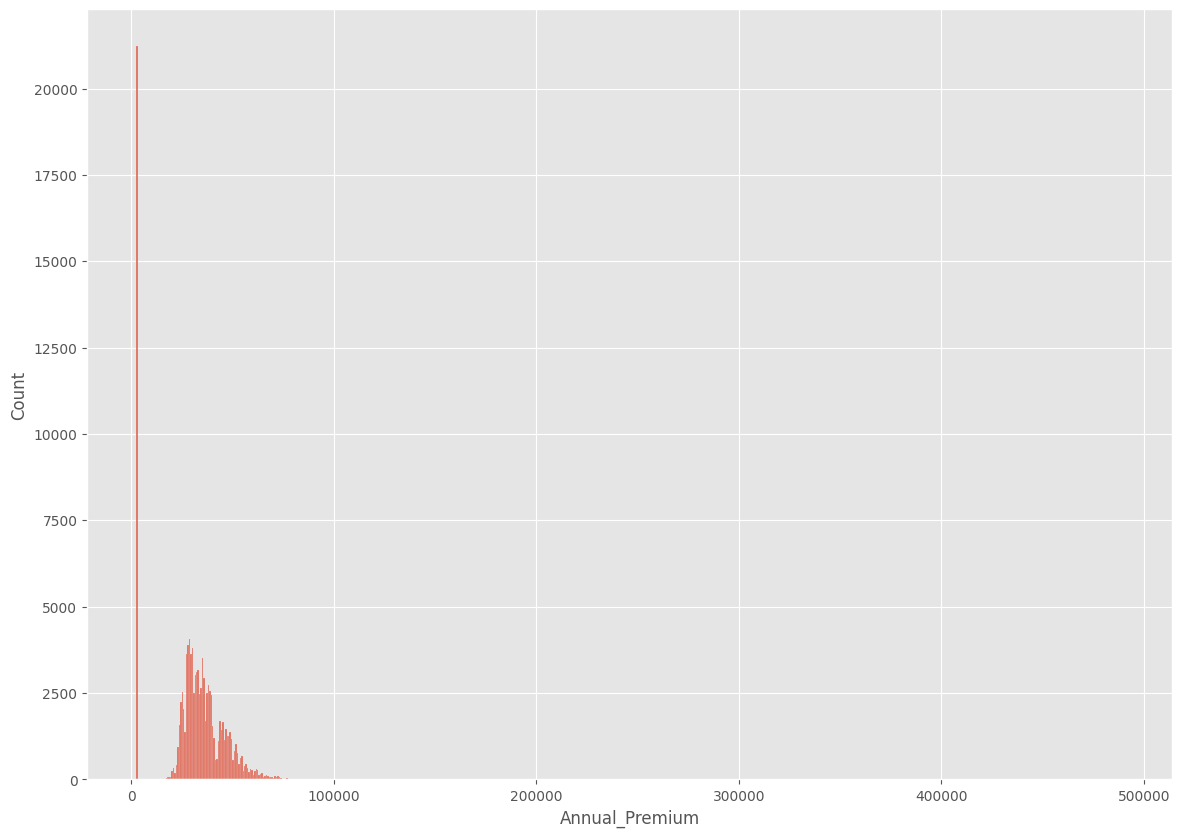

In [152]:
plt.figure(figsize=(14,10))
sns.histplot(data['Annual_Premium'])
plt.show()

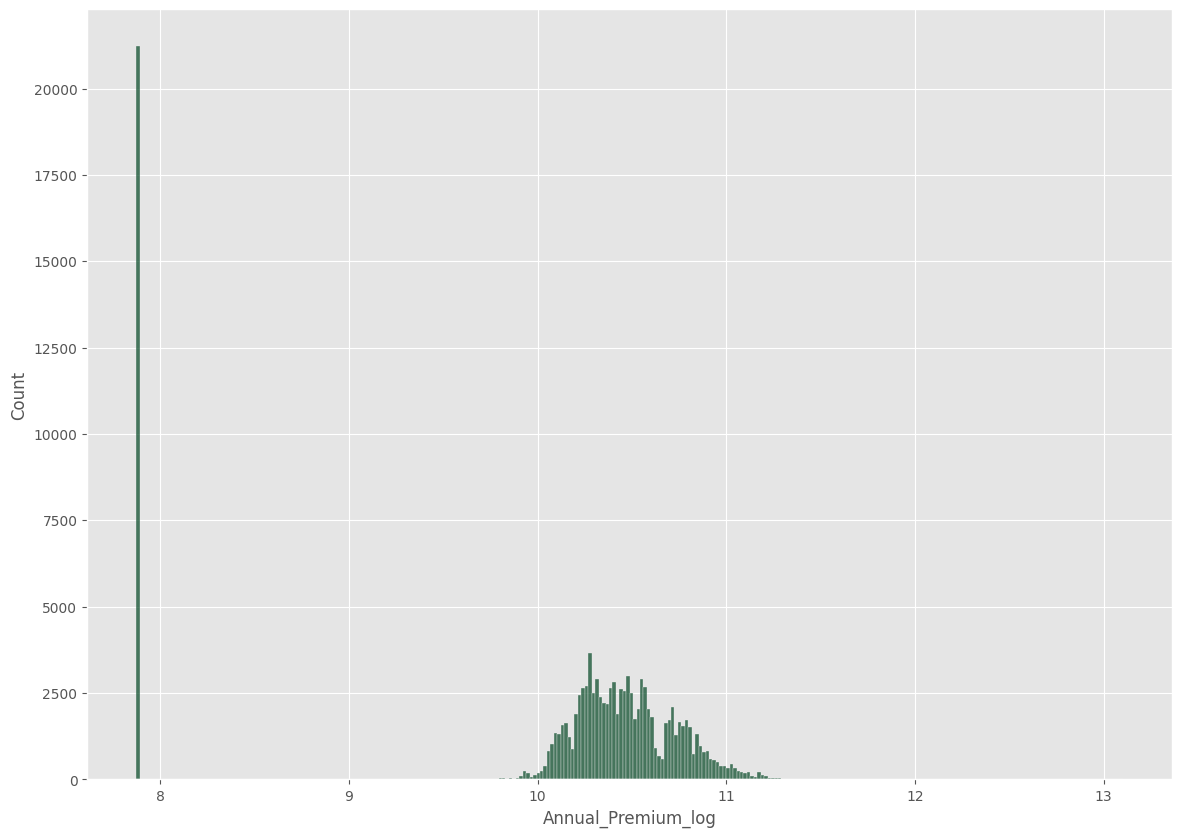

In [153]:
#Прологорифмируем данный признак, чтобы избавиться от негативного влияния выбросов в этом признаке и вновь взглянем на распределение
data['Annual_Premium_log'] = np.log1p(data['Annual_Premium'])
plt.figure(figsize=(14,10))
sns.histplot(data['Annual_Premium_log'], color="#0F502E")
plt.show()

In [154]:
data['Annual_Premium_log'].describe()

count    115048.000000
mean          9.995224
std           1.035423
min           7.875119
25%          10.136700
50%          10.368007
75%          10.582130
max          13.101160
Name: Annual_Premium_log, dtype: float64

После Логарифмирования признака видим, что выбросы подтянулись к основной массе, а распределение приобрело форму напоминающую бимодальную: 1 группа - кто платит минималку по страховке, большой столбец слева; 2 группа широкая группа напоминающая нормальную форму.

In [155]:
group1 = data[data['Annual_Premium_log'] == data['Annual_Premium_log'].min()]
group2 = data[data['Annual_Premium_log'] > data['Annual_Premium_log'].min()]

print(group1.Response.value_counts(normalize=True))
print(group2.Response.value_counts(normalize=True))

#Картина у двух подрупп идентичнна

Response
0    0.870071
1    0.129929
Name: proportion, dtype: float64
Response
0    0.878066
1    0.121934
Name: proportion, dtype: float64


----------------

Policy_Sales_Channel - канал связи с клиентом
---

In [156]:
data.Policy_Sales_Channel.nunique()

123

Policy_Sales_Channel - проверяя разные каналы связи, видим 123 уникальных значения, можно проверить конверсию и также кодировать в несколько групп по показателю конверсии. Но можно еще проверить предварительно конверсию в группах объединенных по значению Региона и Каналу связи. Возьмем самые представленные группы - топ 10 регионов и топ-10 каналов и выделим соответствующие данные.

In [157]:
top_regions = data['Region_Code'].value_counts().head(10).index
top_channels = data['Policy_Sales_Channel'].value_counts().head(10).index

subdata = data[data['Region_Code'].isin(top_regions) & data['Policy_Sales_Channel'].isin(top_channels)]
subdata
#65% данных входят в эту подгруппу

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Annual_Premium_log
10879447,10879447,Female,21,1,8.0,1,< 1 Year,No,40897.0,160.0,173,0,10.618836
10945328,10945328,Female,21,1,8.0,1,< 1 Year,No,34761.0,160.0,232,0,10.456280
8152436,8152436,Female,45,1,28.0,1,1-2 Year,No,36124.0,122.0,193,0,10.494740
7309454,7309454,Male,46,1,28.0,1,1-2 Year,No,35296.0,124.0,199,0,10.471553
1232116,1232116,Male,25,1,28.0,1,< 1 Year,No,27605.0,152.0,283,0,10.225788
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10030697,10030697,Male,24,1,30.0,1,< 1 Year,No,26569.0,152.0,119,0,10.187538
7385351,7385351,Male,36,1,28.0,0,1-2 Year,Yes,33882.0,124.0,161,0,10.430669
11130728,11130728,Male,38,1,8.0,0,1-2 Year,Yes,2630.0,124.0,251,0,7.875119
6109449,6109449,Male,69,1,28.0,0,> 2 Years,Yes,56584.0,26.0,52,0,10.943499


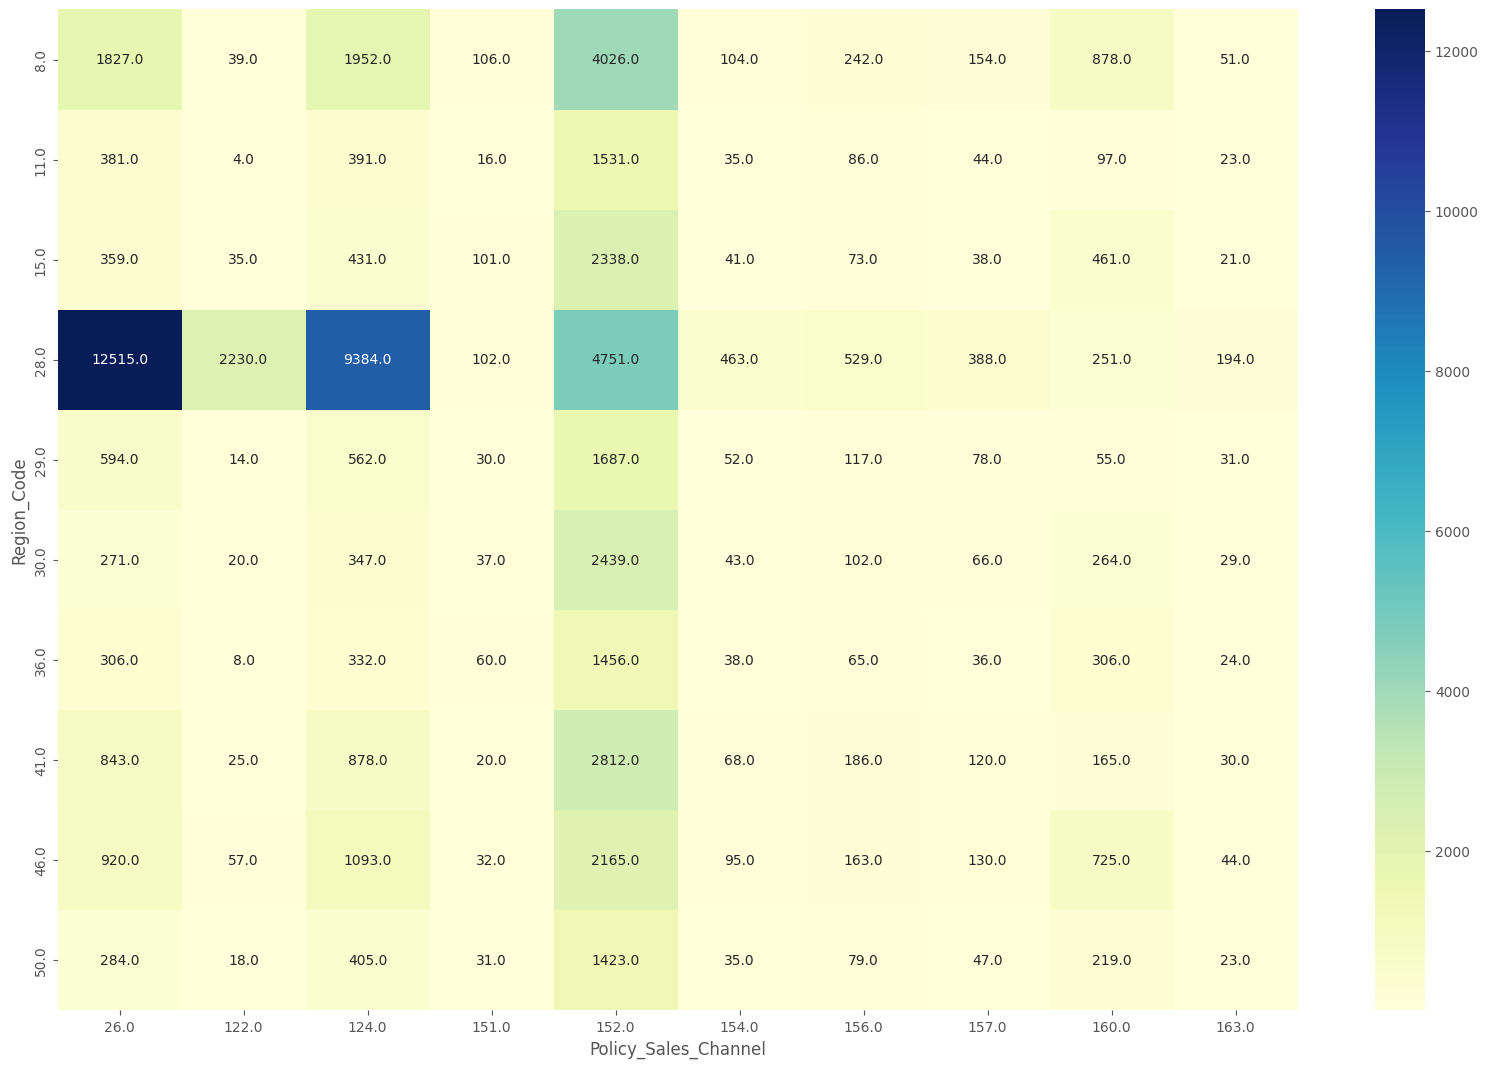

In [158]:
subdata_pivot = subdata.pivot_table(index='Region_Code', columns='Policy_Sales_Channel', values='Response', aggfunc='count')
plt.figure(figsize=(20,13))
sns.heatmap(subdata_pivot,annot=True, fmt='0.1f',cmap='YlGnBu')
plt.show()

Видим, что в разных регионах доминируют разные каналы связи. 152 канал во всех регионах показывает лучшую конверсию, кроме 28 региона - самого представленного в наших данных. В нем 26и 124 показывают заметно более высокую конверсию.
После разделения данных создадим комбинированный признак, который будет состоять из названий Региона и канала, затем заполнен конверсией в этих подгруппе.

-------

Vintage - стаж клиента в днях
---

In [159]:
data.Vintage.describe()

count    115048.000000
mean        163.716570
std          79.817495
min          10.000000
25%          98.000000
50%         166.000000
75%         232.000000
max         299.000000
Name: Vintage, dtype: float64

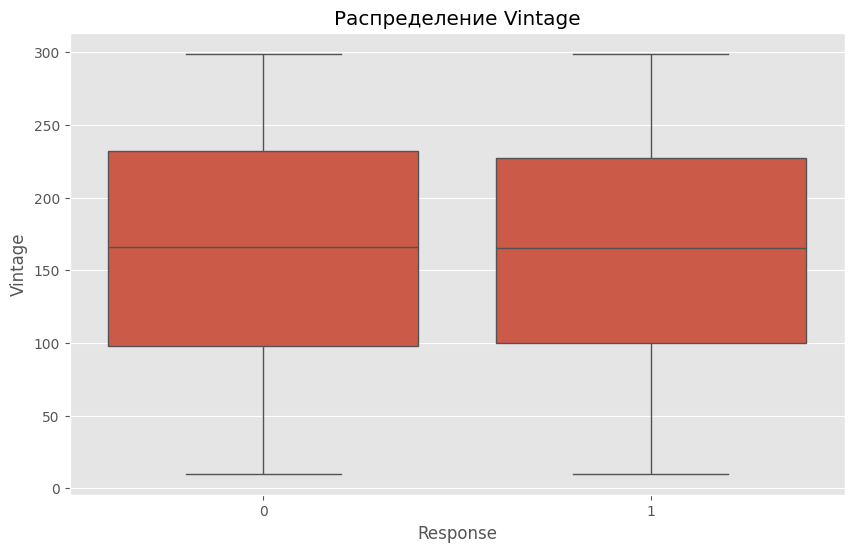

In [160]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Response', y='Vintage') 
plt.title('Распределение Vintage')
plt.show()

Кажется, что этот признак не несет никакой информации полезной. Обе группы на боксплоте имеют одинаковые распределения. Попробуем удалить этот признак, для облегчения моделей.

---------------
---------------


Разделение и предподготовка данных.
---

In [161]:
data.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response', 'Annual_Premium_log'],
      dtype='object')

Удаляем Driving_License, Vintage - бесполезны, Annual_Premium - логарифмировали и создали новый.

Ниже проведем кодирование категориальных признаков.
---

In [162]:
data.drop(['id', 'Driving_License', 'Vintage', 'Annual_Premium'], axis=1, inplace=True)
data.head()

,Gender,Age,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Policy_Sales_Channel,Response,Annual_Premium_log
10879447,Female,21,8.0,1,< 1 Year,No,160.0,0,10.618836
6464385,Female,48,3.0,0,> 2 Years,Yes,124.0,1,10.410998
9428771,Female,38,33.0,1,1-2 Year,No,152.0,0,10.251500
11210897,Female,53,6.0,1,1-2 Year,No,152.0,0,10.248672
10945328,Female,21,8.0,1,< 1 Year,No,160.0,0,10.456280


In [163]:
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})
data['Vehicle_Damage'] = data['Vehicle_Damage'].map({'Yes': 1, 'No':0})

In [164]:
y = data['Response']
X = data.drop(['Response'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=12, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (86286, 8), Test: (28762, 8)


In [165]:
encoder = OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False)

train_ohe = encoder.fit_transform(X_train[['Vehicle_Age']])
test_ohe = encoder.transform(X_test[['Vehicle_Age']])

dummy_cols = encoder.get_feature_names_out(['Vehicle_Age'])
X_train_ohe = pd.DataFrame(train_ohe, columns=dummy_cols, index=X_train.index)
X_test_ohe = pd.DataFrame(test_ohe, columns=dummy_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(['Vehicle_Age'],axis=1), X_train_ohe], axis=1)
X_test = pd.concat([X_test.drop(['Vehicle_Age'],axis=1), X_test_ohe], axis=1)

X_train.head()

,Gender,Age,Region_Code,Previously_Insured,Vehicle_Damage,Policy_Sales_Channel,Annual_Premium_log,Vehicle_Age_1-2 Year,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years
8334239,1,49,26.0,0,0,157.0,7.875119,1.0,0.0,0.0
10597130,1,27,37.0,0,1,152.0,7.875119,0.0,1.0,0.0
9240978,0,23,28.0,1,0,152.0,10.930085,0.0,1.0,0.0
589408,1,47,32.0,1,0,124.0,10.278803,1.0,0.0,0.0
411349,0,27,2.0,1,0,152.0,10.391884,0.0,1.0,0.0


In [166]:
#Region_Code и Policy_Sales_Channel - скомбинируем этот признак и заполнием значениями конверсии, посчитанной по целевой метрике Response.
X_train['Region_Channel'] = X_train['Region_Code'].astype(str) + '-' + X_train['Policy_Sales_Channel'].astype(str)
X_test['Region_Channel'] = X_test['Region_Code'].astype(str) + '-' + X_test['Policy_Sales_Channel'].astype(str)

# Определим среднее значение в обучающей выборке для заполнения им групп, которые будут вновинку в тестовых данных
mean_global = y_train.mean()
# Константа для сглаживания, чтобы группы, в которых было критически мало наблюдений, будет смещать значение в сторону к среднему
m = 10


tab_of_conversion = y_train.groupby(X_train['Region_Channel']).agg(['mean', 'count'])

#Функция для вычисления взвешенного среднего
def func_of_smooth(row):
    count = row['count']
    mean = row['mean']
    return (count*mean + m*mean_global)/(count + m)

encoded = tab_of_conversion.apply(func_of_smooth, axis=1)

X_train['Region_Channel_Enc'] = X_train['Region_Channel'].map(encoded)
X_test['Region_Channel_Enc'] = X_test['Region_Channel'].map(encoded).fillna(mean_global)

X_train.drop(['Region_Channel', 'Region_Code', 'Policy_Sales_Channel'], axis=1, inplace=True)
X_test.drop(['Region_Channel', 'Region_Code', 'Policy_Sales_Channel'], axis=1, inplace=True)

In [167]:
X_train.head()

,Gender,Age,Previously_Insured,Vehicle_Damage,Annual_Premium_log,Vehicle_Age_1-2 Year,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Region_Channel_Enc
8334239,1,49,0,0,7.875119,1.0,0.0,0.0,0.344478
10597130,1,27,0,1,7.875119,0.0,1.0,0.0,0.052121
9240978,0,23,1,0,10.930085,0.0,1.0,0.0,0.038792
589408,1,47,1,0,10.278803,1.0,0.0,0.0,0.215425
411349,0,27,1,0,10.391884,0.0,1.0,0.0,0.022334


Дисбаланс классов
----


In [169]:
y_train.value_counts(normalize=True)


Response
0    0.876596
1    0.123404
Name: proportion, dtype: float64

In [170]:
X_train.to_parquet('X_train_final.parquet')
X_test.to_parquet('X_test_final.parquet')
y_train.to_frame().to_parquet('y_train_final.parquet')
y_test.to_frame().to_parquet('y_test_final.parquet')